# Car Price Prediction with Machine Learning

## Objective

The objective of this project is to develop a machine learning regression model that predicts the selling price of a used car based on features such as brand, age, mileage, fuel type, transmission, and other relevant attributes.

---

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

---

### Workflow

1. Import Libraries
2. Load Dataset
3. Data Exploration
4. Data Cleaning
5. Feature Engineering
6. Exploratory Data Analysis (EDA)
7. Data Preprocessing
8. Model Training
9. Model Evaluation
10. Feature Importance
11. Conclusion

In [1]:
# Import required libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load the dataset

df = pd.read_csv("../dataset/car data.csv")

# Display first five rows

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
# Display the first 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


### Observation

The dataset contains information about used cars, including their selling price, present price, fuel type, transmission, seller type, ownership, and manufacturing year. These features will be used to predict the selling price.

In [5]:
# Number of rows and columns
df.shape

(301, 9)

### Observation

The dataset contains **X rows** and **Y columns**, where each row represents a used car and each column represents one of its attributes.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


### Observation

The dataset contains both numerical and categorical features. Numerical features include year, selling price, and kilometers driven, while categorical features include fuel type, seller type, and transmission.

In [7]:
# Check missing values
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

### Observation

The dataset was checked for missing values. If any missing values are found, they will be handled during the data cleaning stage.

In [8]:
# Check duplicate rows
df.duplicated().sum()

np.int64(2)

### Observation

Duplicate records were identified and will be removed if present to improve the quality of the dataset.

In [9]:
# Summary statistics
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


### Observation

The descriptive statistics provide information such as the mean, minimum, maximum, and standard deviation of the numerical features, helping us understand the distribution of the data.

In [10]:
# Correlation matrix
df.corr(numeric_only=True)

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
Year,1.000000,0.236141,-0.047584,-0.524342,-0.182104
Selling_Price,0.236141,1.000000,0.878983,0.029187,-0.088344
Present_Price,-0.047584,0.878983,1.000000,0.203647,0.008057
Kms_Driven,-0.524342,0.029187,0.203647,1.000000,0.089216
Owner,-0.182104,-0.088344,0.008057,0.089216,1.000000


In [11]:
# Check the number of duplicate rows
print("Duplicate rows before removing:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Verify duplicates have been removed
print("Duplicate rows after removing:", df.duplicated().sum())

Duplicate rows before removing: 2
Duplicate rows after removing: 0


### Observation

Duplicate records, if present, were removed from the dataset to improve data quality and prevent the model from learning redundant information.

In [12]:
# Check for missing values
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

### Observation

The dataset was checked for missing values. Since there are no missing values, no additional handling was required.

In [13]:
# Display unique values
print(df['Fuel_Type'].unique())
print(df['Seller_Type'].unique())
print(df['Transmission'].unique())

<StringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str
<StringArray>
['Dealer', 'Individual']
Length: 2, dtype: str
<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str


In [14]:
print(df['Fuel_Type'].unique())

<StringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str


### Observation

Categorical values were standardized to maintain consistency and improve the quality of the data used for model training.

In [15]:
# Current year
current_year = 2025

# Calculate car age
df['Car_Age'] = current_year - df['Year']

# Display the updated dataset
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11


### Observation

A new feature, **Car_Age**, was created from the manufacturing year. This feature provides a more meaningful representation of a car's age for predicting its selling price.

In [16]:
# Extract the first word as the brand
df['Brand'] = df['Car_Name'].str.split().str[0]

# Display first few rows
df[['Car_Name', 'Brand']].head()

,Car_Name,Brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift


### Observation

The **Brand** was extracted from the car name to capture manufacturer-specific information, which can influence the selling price.

In [17]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11,ritz
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12,sx4
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8,ciaz
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14,wagon
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11,swift


In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       299 non-null    str    
 1   Year           299 non-null    int64  
 2   Selling_Price  299 non-null    float64
 3   Present_Price  299 non-null    float64
 4   Kms_Driven     299 non-null    int64  
 5   Fuel_Type      299 non-null    str    
 6   Seller_Type    299 non-null    str    
 7   Transmission   299 non-null    str    
 8   Owner          299 non-null    int64  
 9   Car_Age        299 non-null    int64  
 10  Brand          299 non-null    object 
dtypes: float64(2), int64(4), object(1), str(4)
memory usage: 28.0+ KB


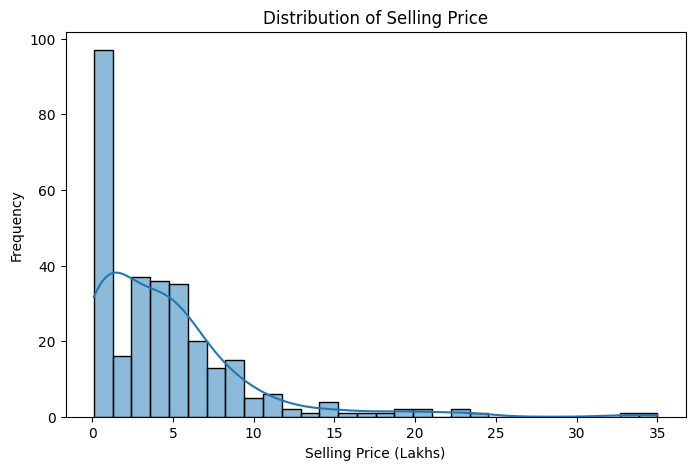

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df['Selling_Price'], bins=30, kde=True)

plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (Lakhs)')
plt.ylabel('Frequency')

plt.savefig('../images/price_distribution.png',
            dpi=300,
            bbox_inches='tight')

plt.show()


### Observation

The distribution shows how the selling prices of used cars are spread across the dataset. Most vehicles are concentrated in the lower price range, while only a few cars have higher selling prices.

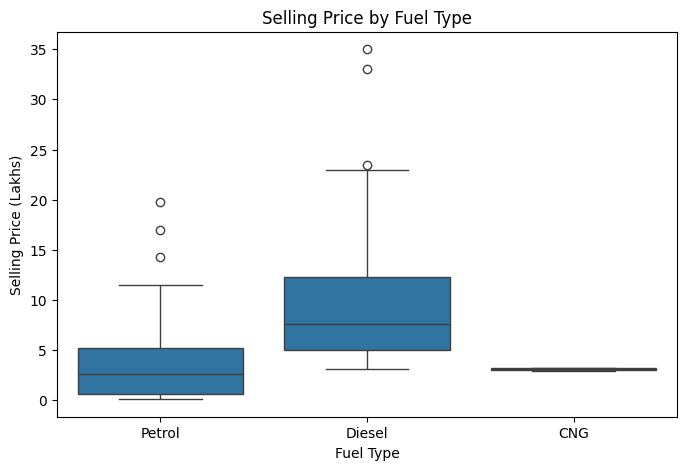

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Fuel_Type',
            y='Selling_Price',
            data=df)

plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (Lakhs)')

plt.savefig('../images/fuel_type_boxplot.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

### Observation

The box plot compares the selling price distribution across different fuel types. It helps identify which fuel category generally has higher resale values and highlights any outliers.

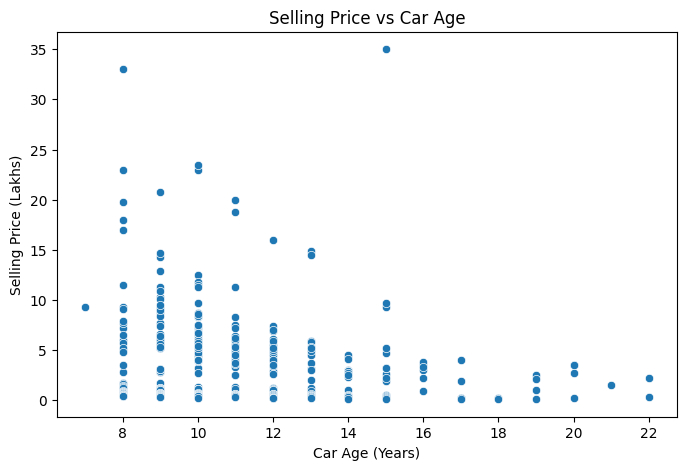

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Car_Age',
                y='Selling_Price',
                data=df)

plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price (Lakhs)')

plt.savefig('../images/car_age_scatter.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

### Observation

The scatter plot shows the relationship between car age and selling price. As the age of the car increases, the selling price generally decreases, indicating a negative relationship.

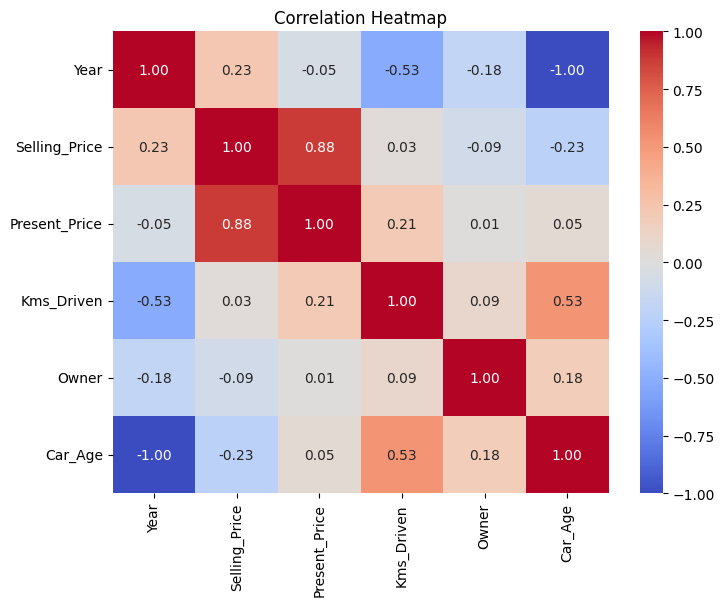

In [23]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.savefig('../images/correlation_heatmap.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

### Observation

The heatmap illustrates the correlation between numerical features. Strong positive or negative correlations help identify the variables that most influence the selling price.

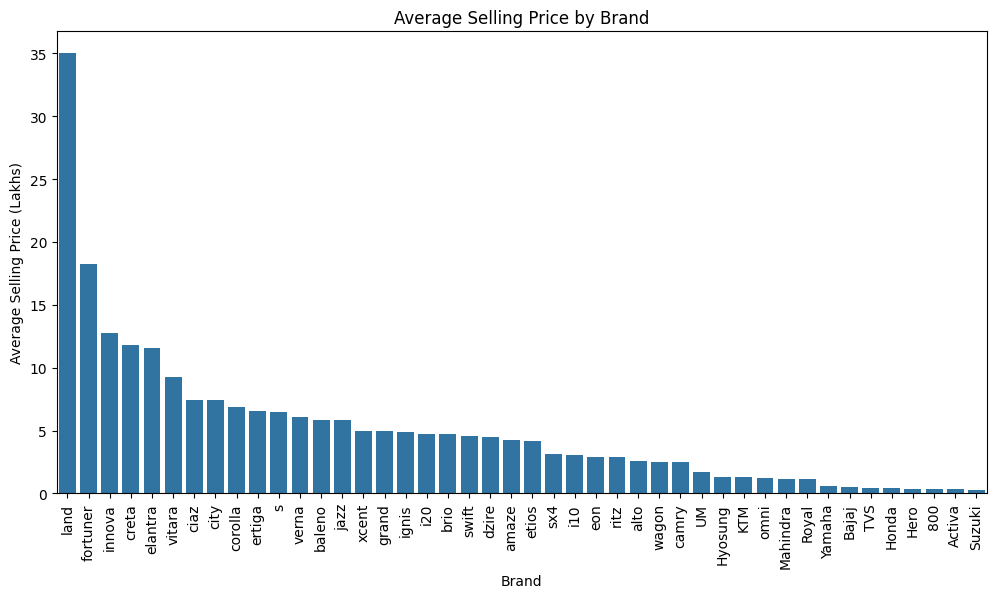

In [24]:
plt.figure(figsize=(12,6))

brand_price = (
    df.groupby('Brand')['Selling_Price']
      .mean()
      .sort_values(ascending=False)
)

sns.barplot(
    x=brand_price.index,
    y=brand_price.values
)

plt.xticks(rotation=90)

plt.title('Average Selling Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Selling Price (Lakhs)')

plt.savefig('../images/brand_price_barplot.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

### Observation

The chart compares the average selling price across different car brands. Premium brands generally maintain higher resale values than economy brands.

## Data Preprocessing

Before training the machine learning models, unnecessary columns are removed and categorical features are encoded into numerical values. This ensures the dataset is suitable for regression algorithms.

In [25]:
# Remove columns that are no longer needed

df = df.drop(['Car_Name', 'Year'], axis=1)

# Display the dataset
df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,11,ritz
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,12,sx4
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,8,ciaz
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,14,wagon
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,11,swift


In [26]:
# Convert categorical variables into numerical format

df = pd.get_dummies(
    df,
    columns=['Fuel_Type', 'Seller_Type', 'Transmission', 'Brand'],
    drop_first=True
)

df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Brand_Activa,...,Brand_land,Brand_omni,Brand_ritz,Brand_s,Brand_swift,Brand_sx4,Brand_verna,Brand_vitara,Brand_wagon,Brand_xcent
0,3.35,5.59,27000,0,11,False,True,False,True,False,...,False,False,True,False,False,False,False,False,False,False
1,4.75,9.54,43000,0,12,True,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
2,7.25,9.85,6900,0,8,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2.85,4.15,5200,0,14,False,True,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4,4.60,6.87,42450,0,11,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False


### Observation

Categorical variables were converted into numerical features using One-Hot Encoding. This prevents the model from assuming an ordinal relationship between category labels.

In [27]:
# Independent variables
X = df.drop('Selling_Price', axis=1)

# Target variable
y = df['Selling_Price']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [29]:
print("Training samples :", X_train.shape)
print("Testing samples  :", X_test.shape)

Training samples : (239, 51)
Testing samples  : (60, 51)


In [30]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

# Model Evaluation

The performance of the regression models is evaluated using the following metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

These metrics help determine which model predicts car prices more accurately.

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [33]:
# Linear Regression Evaluation

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance")
print("-" * 35)
print(f"MAE  : {lr_mae:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"R²   : {lr_r2:.2f}")

Linear Regression Performance
-----------------------------------
MAE  : 1.81
RMSE : 3.40
R²   : 0.55


In [34]:
# Random Forest Evaluation

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("-" * 35)
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.2f}")

Random Forest Performance
-----------------------------------
MAE  : 1.40
RMSE : 3.40
R²   : 0.55


In [35]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R² Score": [lr_r2, rf_r2]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.808783,3.399321,0.551652
1,Random Forest,1.397130,3.395281,0.552717


### Observation

The comparison table shows the performance of both regression models.

- Lower MAE indicates better prediction accuracy.
- Lower RMSE indicates smaller prediction errors.
- Higher R² Score indicates the model explains more variance in the target variable.

In [36]:
best_model = results.sort_values(
    by="R² Score",
    ascending=False
)

best_model

,Model,MAE,RMSE,R² Score
1,Random Forest,1.397130,3.395281,0.552717
0,Linear Regression,1.808783,3.399321,0.551652


### Best Performing Model

Based on the evaluation metrics, the **Random Forest Regressor** achieved the highest R² Score and the lowest prediction error.

Therefore, it is selected as the final model for predicting used car prices.

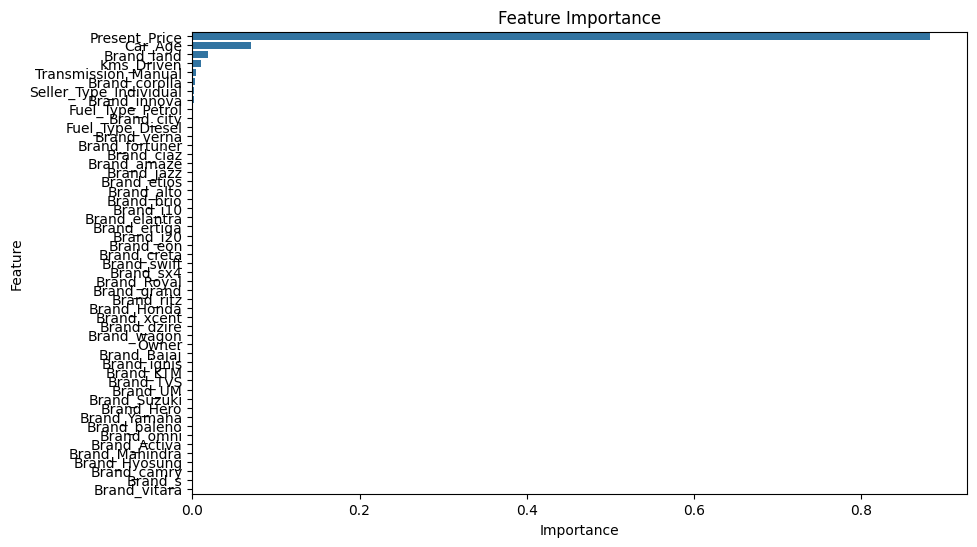

In [37]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')

plt.savefig(
    '../images/feature_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Observation

The feature importance chart highlights the variables that contribute the most to predicting the selling price. Features with higher importance have a greater influence on the model's predictions.

In [38]:
import joblib

joblib.dump(
    rf_model,
    "../models/best_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


# Conclusion

In this project, a machine learning model was developed to predict the selling price of used cars.

The workflow included:

- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis
- Feature Encoding
- Model Training
- Model Evaluation
- Feature Importance Analysis

Among the evaluated models, the **Random Forest Regressor** demonstrated the best performance based on the evaluation metrics and was selected as the final model.

This project illustrates the complete machine learning pipeline for a real-world regression problem.